# Ce abundances in the halo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import paths
from utils import import_sample
from plotting import get_color_list
from sample import abundance_ratio
from stats import median_standard_error

plt.style.use(paths.styles / 'notebook.mplstyle')

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/version.py:137: VersionWarning: Using an un-released version of VICE.
  if not self.isreleased: warnings.warn("""\


In [2]:
sample = import_sample(good_ages=False, cut_limits=True)
sample

,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,...,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr,low_alpha,high_alpha
sdss_id,,,,,,,,,,,,,,,,,,,,,
54381959,2M00224114+5636475,421557607115380608,421557607115380608,403393455,16025,gaia_dr3_source,31,63050394783222145,4291878516,27021597851161007,...,8.590056,0.0,-0.264786,-0.042033,-0.014944,0.014944,0.207808,0.222753,True,False
54381962,NaN,421557744554456064,421557744554456064,403393481,16025,tic_v8,25,27021597851161095,4291878605,27021597851161095,...,9.153462,0.0,-0.242691,0.026106,0.002166,-0.002166,0.270964,0.268797,True,False
54381968,2M00220667+5639444,421558740986710784,421558740986710784,403316795,16025,gaia_dr3_source,31,63050394783222492,4291878364,27021597851160855,...,10.254416,0.0,-0.114196,0.175422,-0.022203,0.022203,0.267416,0.289618,True,False
54381984,2M00223542+5645497,421560390254274304,421560390254274304,403393131,16025,gaia_dr3_source,31,63050394783223054,4291881586,27021597851164071,...,9.035937,0.0,0.060240,0.138027,0.046850,-0.046850,0.124637,0.077787,True,False
54382000,2M00220711+5648323,421561489765700224,421561489765700224,403317093,16025,gaia_dr3_source,31,63050394783223394,4291881416,27021597851163901,...,14.852359,0.0,-0.184421,-0.040208,0.003985,-0.003985,0.148199,0.144213,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129060797,2M08543799-4600155,5331153616728690432,5331153616728690432,29951519,169169,gaia_dr3_source,31,63050395878304977,5803209549,27021599359029628,...,7.758100,0.0,-0.061466,0.193908,0.046129,-0.046129,0.301503,0.255374,True,False
129060805,2M08300191-3959403,5527814224979419776,5527814224979419776,184540591,161717,gaia_dr3_source,31,63050395950376805,5809725641,27021599365533938,...,10.770966,0.0,-0.525602,-0.549366,-0.062440,0.062440,-0.086203,-0.023763,True,False
129060884,2M09110058-4849577,5326021096449688064,5326021096449688064,364057991,172356,gaia_dr3_source,31,63050395875982757,5802300216,27021599358122770,...,4.912325,0.0,-0.365320,-0.171740,-0.013284,0.013284,0.180296,0.193580,True,False


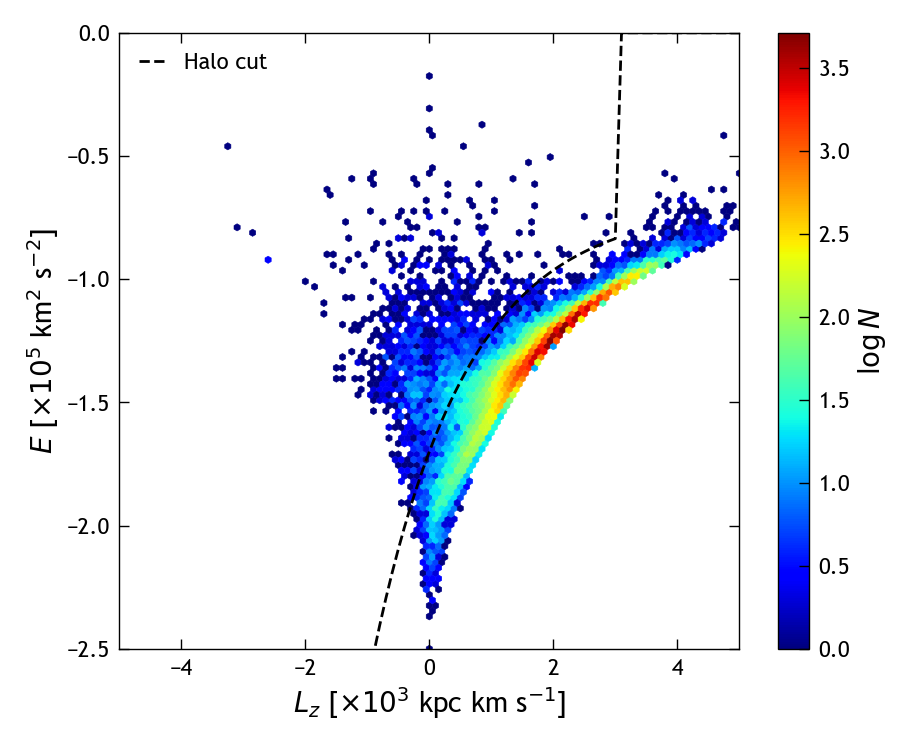

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))

logsum = lambda x: np.log10(np.sum(x))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-5, 5, -2.5, 0.])
pcm = ax.hexbin(
    -sample['Lz']/1e3, sample['E']/1e5, 
    C=np.ones(sample.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

# Arbitrary cut - find a better one in the literature
def halo_ELz_cut(Lz):
    return np.where(Lz<-3, 0, -0.7 - np.exp(Lz / 1.5))

Lz_arr = np.arange(-5, 5.1, 0.1)
ax.plot(Lz_arr, halo_ELz_cut(-Lz_arr), 'k--', label='Halo cut')

ax.set_xlabel(r'$L_z$ [$\times10^3$ kpc km s$^{-1}$]')
ax.set_ylabel(r'$E$ [$\times 10^5$ km$^2$ s$^{-2}$]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

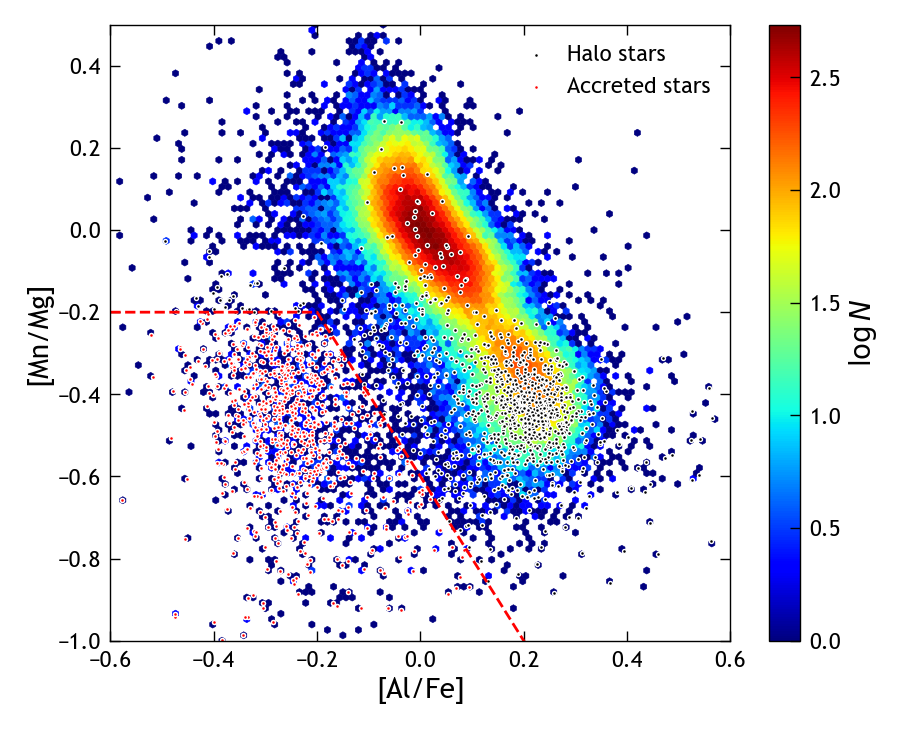

In [4]:
mwm_halo = sample[sample['E']/1e5 > halo_ELz_cut(sample['Lz']/1e3)]
mwm_disk = sample[sample['E']/1e5 < halo_ELz_cut(sample['Lz']/1e3)]

fig, ax = plt.subplots(figsize=(5, 4))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-0.6, 0.6, -1, 0.5])
pcm = ax.hexbin(
    sample['al_fe'], sample['mn_mg'], 
    C=np.ones(sample.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

ax.scatter(mwm_halo['al_fe'], mwm_halo['mn_mg'], rasterized=True, edgecolors='w', linewidths=0.5, s=2, c='k', label='Halo stars')

def accreted_boundary(alfe):
    return np.where(alfe > -0.2, -0.6-2*alfe, -0.2)

alfe_arr = np.arange(-0.6, 0.5, 0.1)
ax.plot(alfe_arr, accreted_boundary(alfe_arr), 'r--')

mwm_accreted = mwm_halo[mwm_halo['mn_mg'] < accreted_boundary(mwm_halo['al_fe'])]
mwm_halo_in_situ = mwm_halo[mwm_halo['mn_mg'] > accreted_boundary(mwm_halo['al_fe'])]
ax.scatter(mwm_accreted['al_fe'], mwm_accreted['mn_mg'], rasterized=True, edgecolors='w', linewidths=0.5, s=2, c='r', label='Accreted stars')

ax.set_xlabel('[Al/Fe]')
ax.set_ylabel('[Mn/Mg]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

In [5]:
sample_with_limits = import_sample(good_ages=False, cut_limits=False)

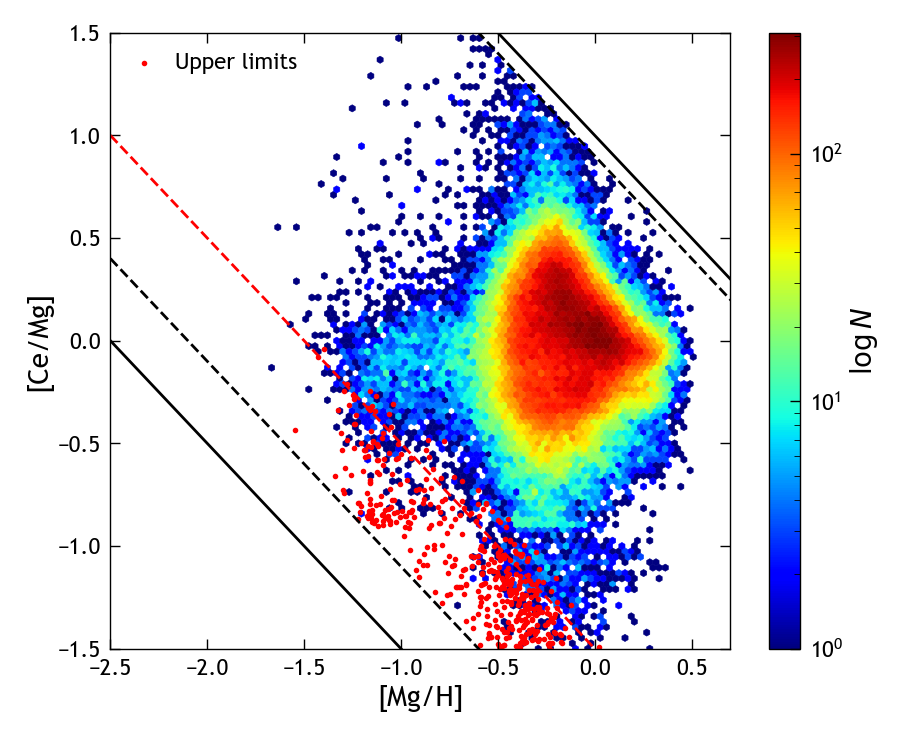

In [6]:

ce_limits = sample_with_limits[sample_with_limits['lim_ce_h_flag']==1]

fig, ax = plt.subplots(figsize=(5, 4))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-2.5, 0.7, -1.5, 1.5])
pcm = ax.hexbin(
    sample['mg_h'], sample['ce_mg'], 
    C=np.ones(sample.shape[0]),
    reduce_C_function=np.sum,
    norm=LogNorm(),
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

# ax.scatter(mwm_halo['mg_h'], mwm_halo['ce_mg'], rasterized=True, edgecolors='w', linewidths=0.5, s=2, c='k', label='Halo stars')
ax.scatter(ce_limits['mg_h'], ce_limits['ce_mg'], c='r', s=1, label='Upper limits')

# Indicate grid edges
mgh_arr = np.arange(-2.5, 1.25, 0.25)
ax.plot(mgh_arr, -2.5 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, -2.1 - mgh_arr, 'k--') # edge of stars flagged bad
ax.plot(mgh_arr, -1.5 - mgh_arr, 'r--') # indicates region of upper limits (manual)
ax.plot(mgh_arr, 1 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, 0.9 - mgh_arr, 'k--') # edge of stars flagged bad

ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

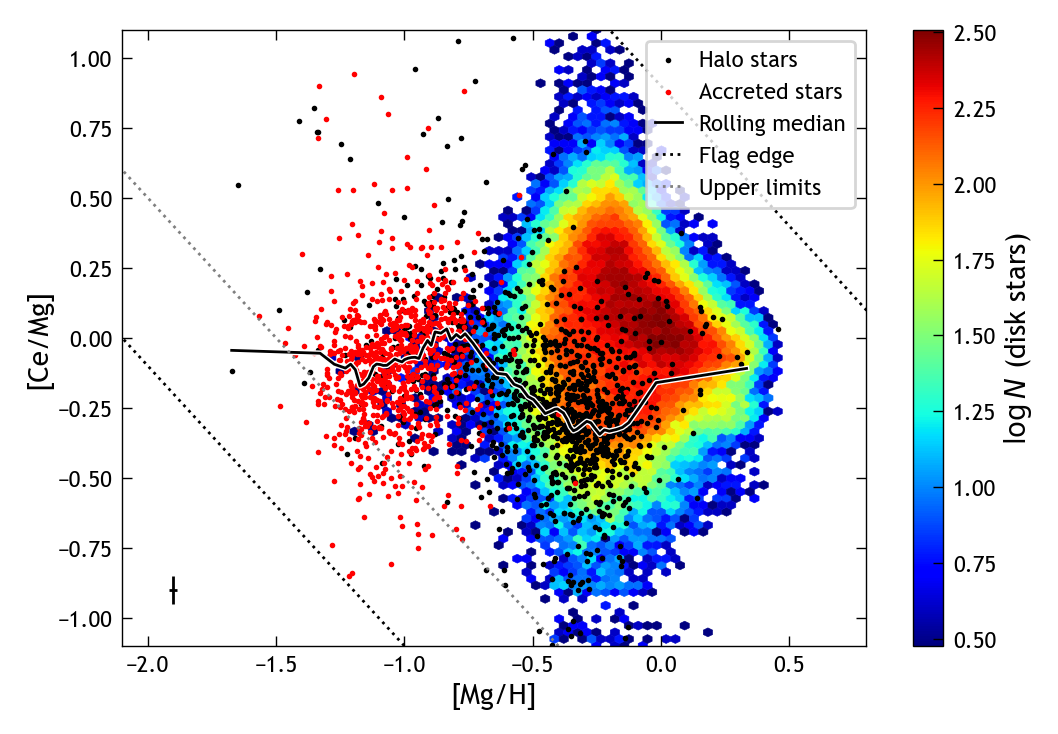

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

kwargs = dict(gridsize=80, cmap='jet', linewidths=0.2, extent=[-2.1, 0.8, -1.1, 1.1], mincnt=3)
pcm = ax.hexbin(
    mwm_disk['mg_h'], mwm_disk['ce_mg'], 
    C=np.ones(sample.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$ (disk stars)')

ax.scatter(mwm_halo_in_situ['mg_h'], mwm_halo_in_situ['ce_mg'], rasterized=True, s=1, c='k', label='Halo stars')
ax.scatter(mwm_accreted['mg_h'], mwm_accreted['ce_mg'], rasterized=True, s=1, c='r', label='Accreted stars')

# Indicate median abundance error
ax.errorbar(
    -1.9, -0.9, 
    xerr=sample['e_mg_h'].median(), 
    yerr=sample['e_ce_mg'].median(),
    c='k', capsize=0
)

# Rolling median
sorted_data = mwm_halo.sort_values('mg_h')[['mg_h', 'ce_mg']]
rolling_medians = sorted_data.rolling(
    100, min_periods=30, step=30, on='mg_h', center=True
).median()
ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], 'w-', linewidth=2)
ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], 'k-', label='Rolling median')

# Indicate grid edges
mgh_arr = np.arange(-2.5, 1.25, 0.25)
# ax.plot(mgh_arr, -2.5 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, -2.1 - mgh_arr, 'k:', label='Flag edge') # edge of stars flagged bad
ax.plot(mgh_arr, -1.5 - mgh_arr, color='gray', ls=':', label='Upper limits') # indicates region of upper limits (manual)
# ax.plot(mgh_arr, 1 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, 0.9 - mgh_arr, 'k:') # edge of stars flagged bad

ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend(frameon=True, loc='upper right')

plt.show()

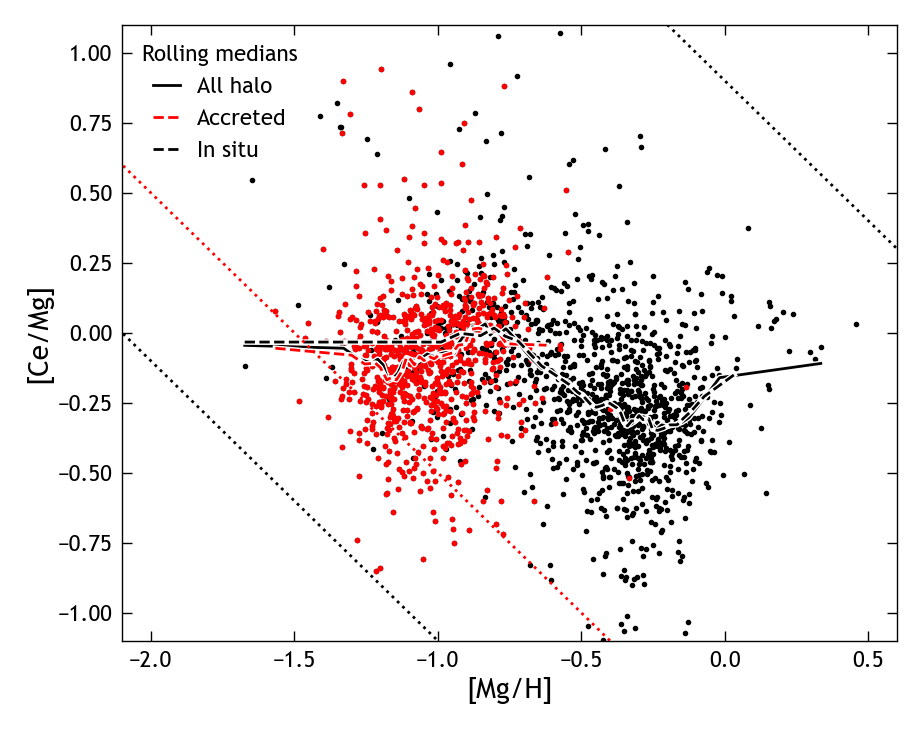

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(mwm_halo['mg_h'], mwm_halo['ce_mg'], rasterized=True, s=1, c='k')
ax.scatter(mwm_accreted['mg_h'], mwm_accreted['ce_mg'], rasterized=True, s=1, c='r')

# Rolling median
fmt = ['k-', 'r--', 'k--']
labels = ['All halo', 'Accreted', 'In situ']
for i, data in enumerate([mwm_halo, mwm_accreted, mwm_halo_in_situ]):
    sorted_data = data.sort_values('mg_h')[['mg_h', 'ce_mg']]
    rolling_medians = sorted_data.rolling(
        100, min_periods=30, step=30, on='mg_h', center=True
    ).median()
    ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], 'w-', linewidth=2)
    ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], fmt[i], label=labels[i])

# Indicate grid edges
mgh_arr = np.arange(-2.5, 1.25, 0.25)
# ax.plot(mgh_arr, -2.5 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, -2.1 - mgh_arr, 'k:') # edge of stars flagged bad
ax.plot(mgh_arr, -1.5 - mgh_arr, 'r:') # indicates region of upper limits (manual)
# ax.plot(mgh_arr, 1 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, 0.9 - mgh_arr, 'k:') # edge of stars flagged bad

ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((-2.1, 0.6))
ax.set_ylim((-1.1, 1.1))
ax.legend(title='Rolling medians')

plt.show()

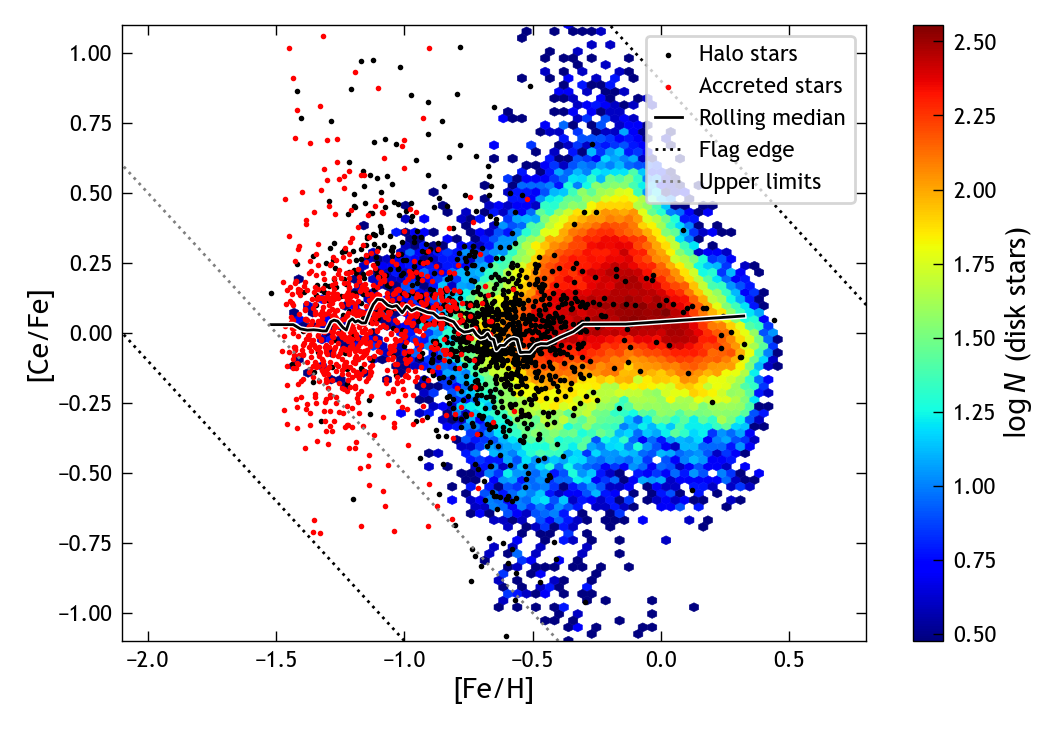

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

kwargs = dict(gridsize=80, cmap='jet', linewidths=0.2, extent=[-2.1, 0.8, -1.1, 1.1], mincnt=3)
pcm = ax.hexbin(
    mwm_disk['fe_h'], mwm_disk['ce_fe'], 
    C=np.ones(sample.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$ (disk stars)')

ax.scatter(mwm_halo_in_situ['fe_h'], mwm_halo_in_situ['ce_fe'], rasterized=True, s=1, c='k', label='Halo stars')
ax.scatter(mwm_accreted['fe_h'], mwm_accreted['ce_fe'], rasterized=True, s=1, c='r', label='Accreted stars')

# Rolling median
sorted_data = mwm_halo.sort_values('fe_h')[['fe_h', 'ce_fe']]
rolling_medians = sorted_data.rolling(
    100, min_periods=30, step=30, on='fe_h', center=True
).median()
ax.plot(rolling_medians['fe_h'], rolling_medians['ce_fe'], 'w-', linewidth=2)
ax.plot(rolling_medians['fe_h'], rolling_medians['ce_fe'], 'k-', label='Rolling median')

# Indicate grid edges
mgh_arr = np.arange(-2.5, 1.25, 0.25)
# ax.plot(mgh_arr, -2.5 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, -2.1 - mgh_arr, 'k:', label='Flag edge') # edge of stars flagged bad
ax.plot(mgh_arr, -1.5 - mgh_arr, color='gray', ls=':', label='Upper limits') # indicates region of upper limits (manual)
# ax.plot(mgh_arr, 1 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, 0.9 - mgh_arr, 'k:') # edge of stars flagged bad

ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Ce/Fe]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend(frameon=True, loc='upper right')

plt.show()

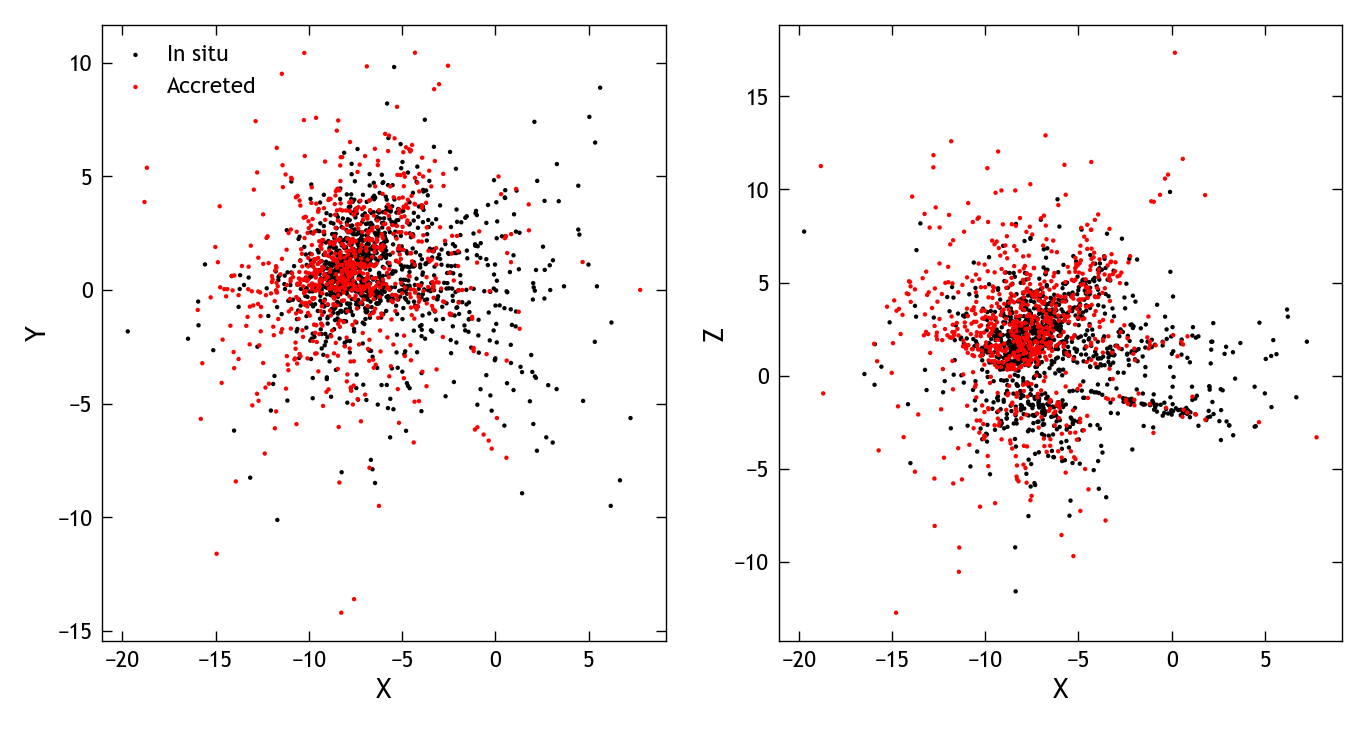

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
scatter_kwargs = dict(s=10, marker='.', edgecolors='none')
axs[0].scatter(mwm_halo_in_situ['galx'], mwm_halo_in_situ['galy'], c='k', label='In situ', **scatter_kwargs)
axs[0].scatter(mwm_accreted['galx'], mwm_accreted['galy'], c='r', label='Accreted', **scatter_kwargs)
axs[1].scatter(mwm_halo_in_situ['galx'], mwm_halo_in_situ['galz'], c='k', **scatter_kwargs)
axs[1].scatter(mwm_accreted['galx'], mwm_accreted['galz'], c='r',  **scatter_kwargs)
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Z')
axs[0].legend()
plt.show()

In [11]:
in_situ_retro = mwm_halo_in_situ[mwm_halo_in_situ['Lz']/mwm_halo_in_situ['Jtot'] > 0.3]
in_situ_retro

,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,...,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr,low_alpha,high_alpha
sdss_id,,,,,,,,,,,,,,,,,,,,,
56504377,2M08515765+2507466,690030996260272384,690030996260272384,355125807,56765,gaia_dr3_source,31,63050394821281114,4555111074,27021598112582072,...,3.691722,0.0,-0.425020,-0.327639,-0.176998,0.176998,-0.079616,0.097382,False,True
56639764,2M09053367+3145279,712158152372279936,712158152373616512,166645315,46530,gaia_dr3_source,31,63050394821846423,4596579330,27021599488626659,...,3.584604,0.0,-1.001005,-0.041321,-0.222933,0.222933,0.736752,0.959685,False,False
56836168,2M10302322+3453517,749765882448015232,749765882448015232,407612293,41952,gaia_dr3_source,31,63050394822533735,4597532831,27021598154583535,...,4.990353,0.0,-0.659698,-0.580146,-0.298625,0.298625,-0.219074,0.079551,False,True
57213244,2M10130191+4840467,822929275947657344,822929275947657344,371544004,24167,gaia_dr3_source,31,63050394823804608,4360616773,27021597919444669,...,2.384439,0.0,-0.672246,-0.694603,0.093441,-0.093441,0.071083,-0.022357,True,False
57408711,NaN,858315472842851072,858315472842851072,310932485,14104,tic_v8,25,27021597918515216,4359660172,27021597918515216,...,2.562456,0.0,-0.569090,-0.482267,-0.118407,0.118407,-0.031584,0.086823,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113678383,2M18545102-2828189,6761937102836050048,6761937102836050048,90902260,145555,gaia_dr3_source,31,63050396533446239,4969163071,27021598525902809,...,2.434002,0.0,-0.869516,-0.859777,-0.320244,0.320244,-0.310504,0.009739,False,True
114484916,NaN,6876428015985242752,6876428015985242752,114725492,121522,tic_v8,25,27021598718056299,5161426929,27021598718056299,...,1.686651,0.0,-1.009178,-0.868734,-0.265085,0.265085,-0.124641,0.140444,False,True
114726386,NaN,6907573194667018624,6907573194667018624,9558243,110775,tic_v8,25,27021598724980719,5168370440,27021598724980719,...,2.443145,0.0,-0.342266,-0.182657,-0.238674,0.238674,-0.079065,0.159609,False,True


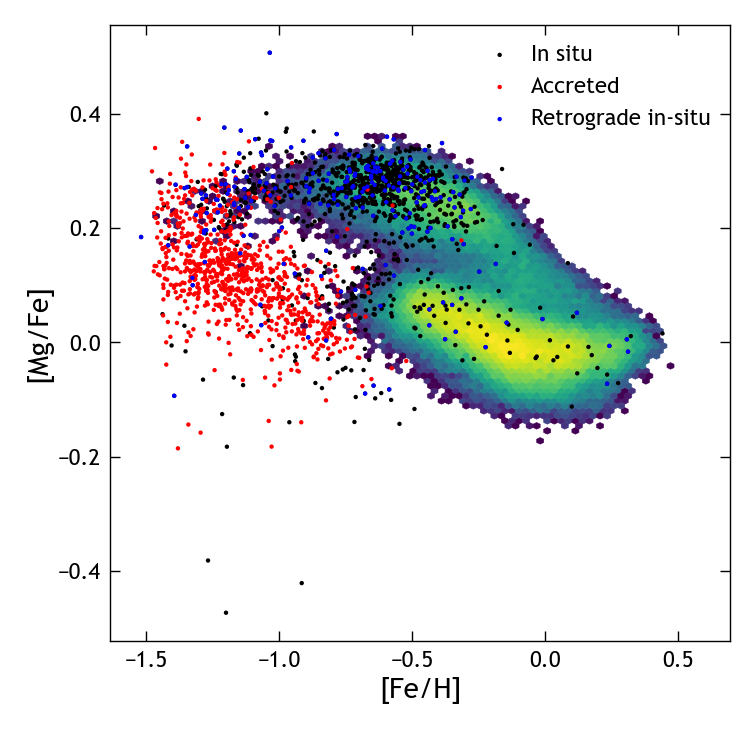

In [12]:
fig, ax = plt.subplots()
kwargs = dict(gridsize=80, cmap='viridis', linewidths=0.2, mincnt=3)
pcm = ax.hexbin(
    mwm_disk['fe_h'], mwm_disk['mg_fe'], 
    C=np.ones(sample.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
ax.scatter(mwm_halo_in_situ['fe_h'], mwm_halo_in_situ['mg_fe'], c='k', label='In situ', **scatter_kwargs)
ax.scatter(mwm_accreted['fe_h'], mwm_accreted['mg_fe'], c='r', label='Accreted', **scatter_kwargs)
ax.scatter(in_situ_retro['fe_h'], in_situ_retro['mg_fe'], c='b', label='Retrograde in-situ', **scatter_kwargs)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')
ax.legend()
plt.show()

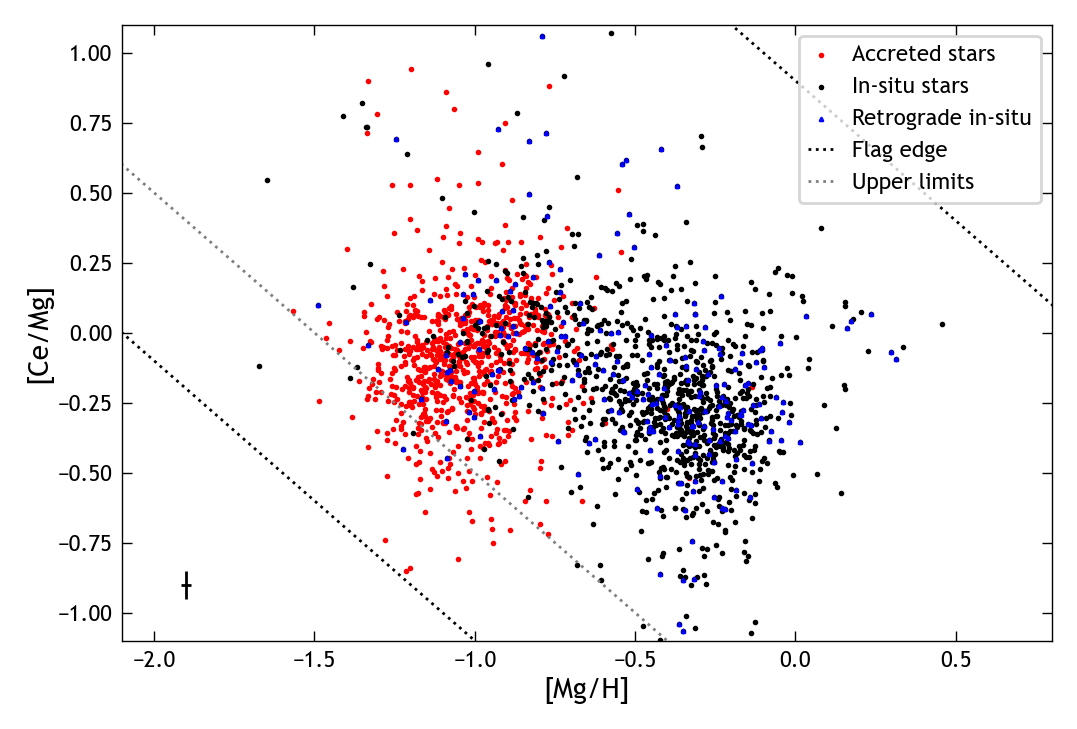

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

kwargs = dict(gridsize=80, cmap='jet', linewidths=0.2, extent=[-2.1, 0.8, -1.1, 1.1], mincnt=3)
# pcm = ax.hexbin(
#     mwm_disk['mg_h'], mwm_disk['ce_mg'], 
#     C=np.ones(sample.shape[0]),
#     reduce_C_function=logsum,
#     **kwargs
# )
# fig.colorbar(pcm, ax=ax, label=r'$\log N$ (disk stars)')

ax.scatter(mwm_accreted['mg_h'], mwm_accreted['ce_mg'], rasterized=True, s=1, c='r', label='Accreted stars')
ax.scatter(mwm_halo_in_situ['mg_h'], mwm_halo_in_situ['ce_mg'], rasterized=True, s=1, c='k', label='In-situ stars')
ax.scatter(in_situ_retro['mg_h'], in_situ_retro['ce_mg'], rasterized=True, s=1, c='b', marker='^', label='Retrograde in-situ')

# Indicate median abundance error
ax.errorbar(
    -1.9, -0.9, 
    xerr=sample['e_mg_h'].median(), 
    yerr=sample['e_ce_mg'].median(),
    c='k', capsize=0
)

# Rolling median
# sorted_data = mwm_halo.sort_values('mg_h')[['mg_h', 'ce_mg']]
# rolling_medians = sorted_data.rolling(
#     100, min_periods=30, step=30, on='mg_h', center=True
# ).median()
# ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], 'w-', linewidth=2)
# ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], 'k-', label='Rolling median')

# Indicate grid edges
mgh_arr = np.arange(-2.5, 1.25, 0.25)
# ax.plot(mgh_arr, -2.5 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, -2.1 - mgh_arr, 'k:', label='Flag edge') # edge of stars flagged bad
ax.plot(mgh_arr, -1.5 - mgh_arr, color='gray', ls=':', label='Upper limits') # indicates region of upper limits (manual)
# ax.plot(mgh_arr, 1 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, 0.9 - mgh_arr, 'k:') # edge of stars flagged bad

ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend(frameon=True, loc='upper right')

plt.show()

## Action diamond

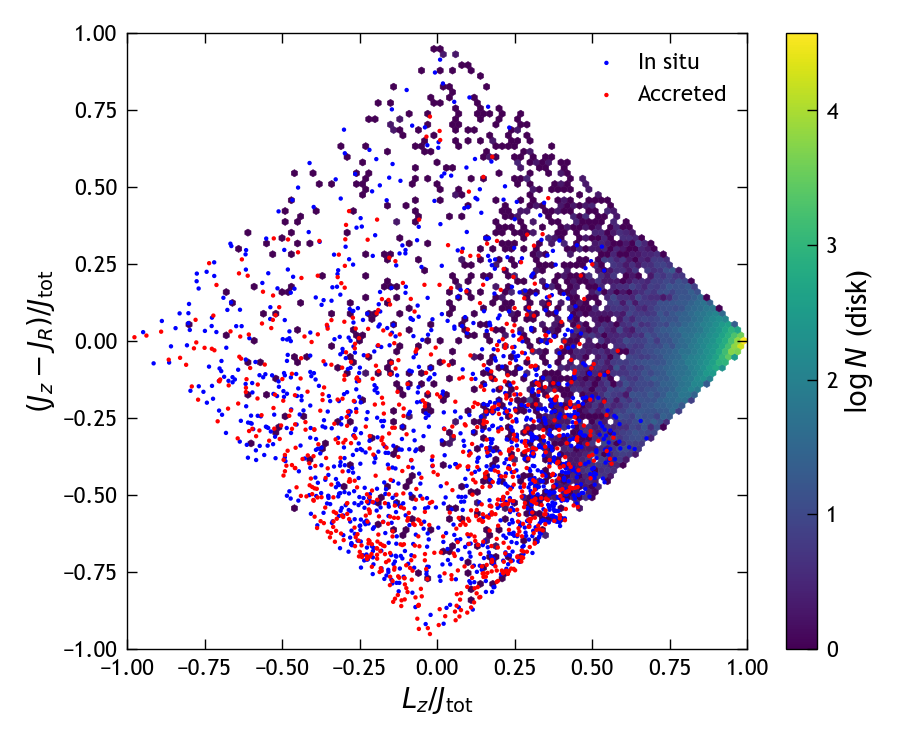

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))

logsum = lambda x: np.log10(np.sum(x))

# Define total action Jtot
# sample['Jtot'] = sample['Jr'].abs() + sample['Jz'].abs() + sample['Lz'].abs()

kwargs = dict(gridsize=100, cmap='viridis', linewidths=0.2, extent=[-1, 1, -1, 1])
pcm = ax.hexbin(
    -mwm_disk['Lz']/mwm_disk['Jtot'], 
    (mwm_disk['Jz']-mwm_disk['Jr'])/mwm_disk['Jtot'], 
    C=np.ones(mwm_disk.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$ (disk)')
ax.scatter(
    -mwm_halo_in_situ['Lz']/mwm_halo_in_situ['Jtot'], 
    (mwm_halo_in_situ['Jz']-mwm_halo_in_situ['Jr'])/mwm_halo_in_situ['Jtot'], 
    c='b', label='In situ', **scatter_kwargs
)
ax.scatter(
    -mwm_accreted['Lz']/mwm_accreted['Jtot'], 
    (mwm_accreted['Jz']-mwm_accreted['Jr'])/mwm_accreted['Jtot'], 
    c='r', label='Accreted', **scatter_kwargs
)

ax.set_xlabel(r'$L_z/J_{\rm tot}$')
ax.set_ylabel(r'$(J_z - J_R)/J_{\rm tot}$')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

/var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_87106/3228566537.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


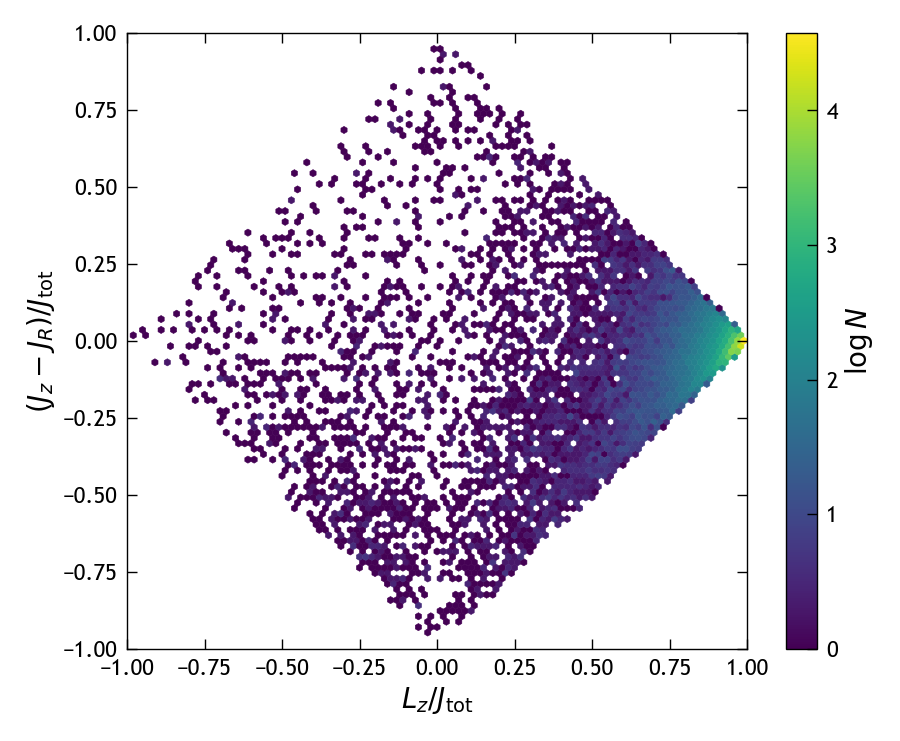

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))

logsum = lambda x: np.log10(np.sum(x))

# Define total action Jtot
sample['Jtot2'] = np.sqrt(sample['Jr']**2 + sample['Jz']**2 + sample['Lz']**2)

kwargs = dict(gridsize=100, cmap='viridis', linewidths=0.2, extent=[-1, 1, -1, 1])
pcm = ax.hexbin(
    -sample['Lz']/sample['Jtot'], 
    (sample['Jz']-sample['Jr'])/sample['Jtot'], 
    C=np.ones(sample.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

ax.set_xlabel(r'$L_z/J_{\rm tot}$')
ax.set_ylabel(r'$(J_z - J_R)/J_{\rm tot}$')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

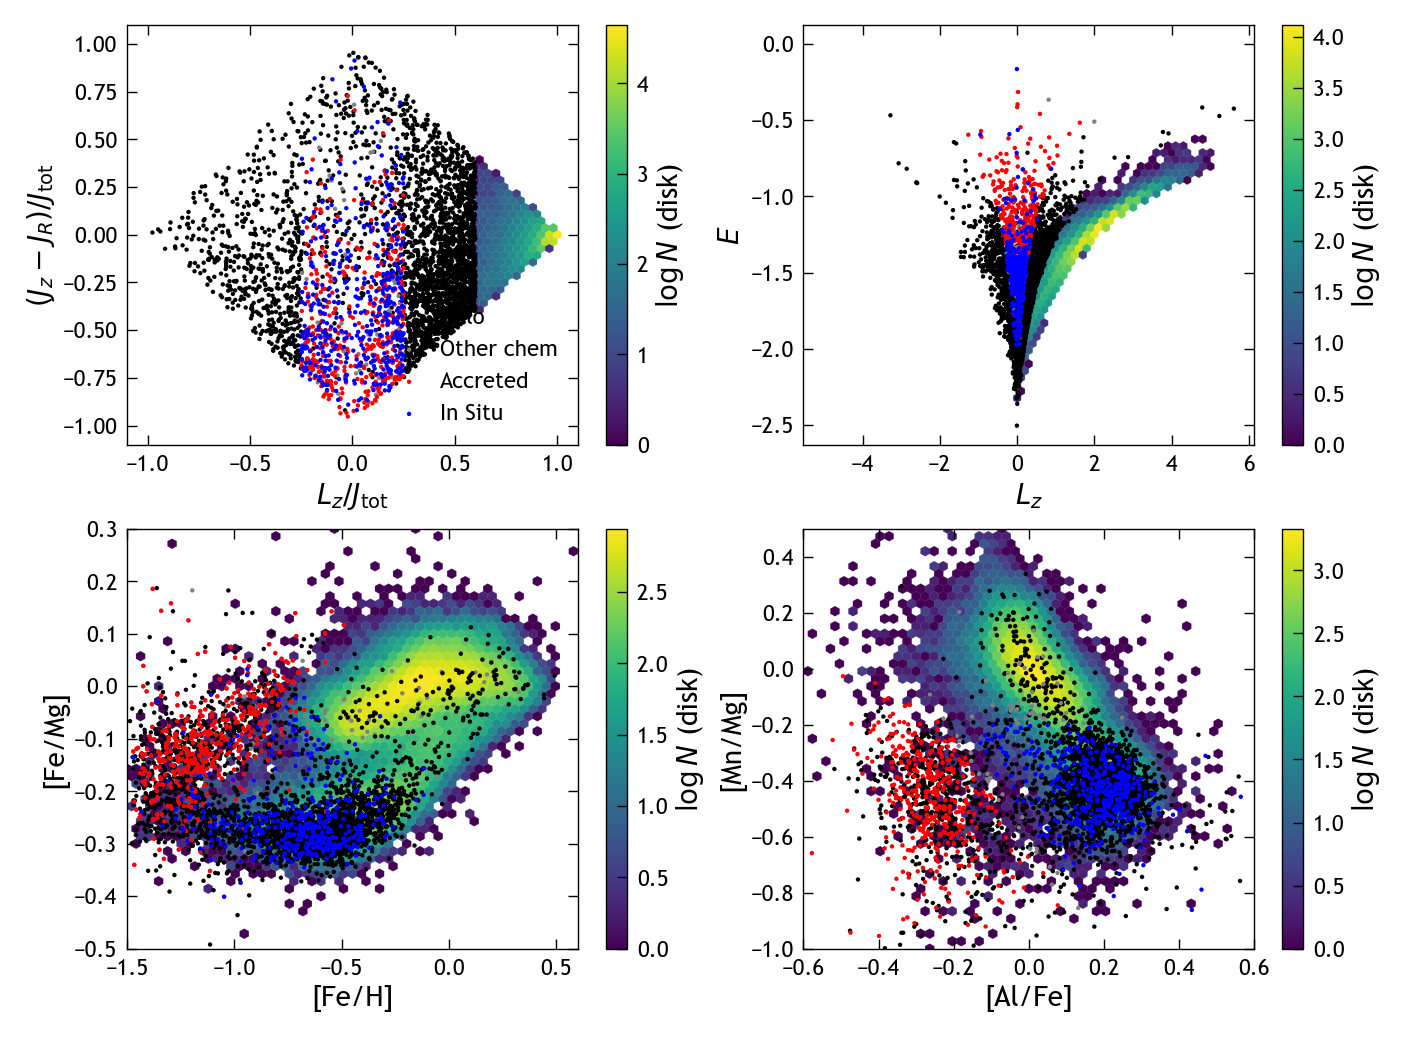

In [60]:
fig, axs = plt.subplots(2, 2, figsize=(8, 6))

logsum = lambda x: np.log10(np.sum(x))
x = -sample['Lz']/sample['Jtot']-1
y = (sample['Jz']-sample['Jr'])/sample['Jtot']
a = 0.6*np.sqrt(2)
b = 0.6*np.sqrt(2)
theta = np.pi/4
# ad_halo_mask = b**2*(x*np.cos(theta)+y*np.sin(theta))**2 + a**2*(y*np.cos(theta)-x*np.sin(theta))**2 > a**2 * b**2
ad_halo_mask = (np.abs(sample['Lz']/sample['Jtot']) < 0.25) & (sample['galr'] > 3)# & (sample['galz'].abs() > 1)
ad_halo = sample[ad_halo_mask]
ad_disk_mask = -sample['Lz']/sample['Jtot'] > 0.6
ad_disk = sample[ad_disk_mask]
ad_other = sample[(~ad_disk_mask) & (~ad_halo_mask)]

chem_accreted_mask = (sample['mn_mg'] < -0.65-2*sample['al_fe'])
chem_insitu_mask = (sample['mn_mg'] > -0.55-2*sample['al_fe']) & (sample['mn_mg'] < -0.2)
ad_accreted = sample[ad_halo_mask & chem_accreted_mask]
ad_insitu = sample[ad_halo_mask & chem_insitu_mask]
ad_neither = sample[ad_halo_mask & ~(chem_insitu_mask) & ~(chem_accreted_mask)]

# Panel 1: Action Diamond
kwargs = dict(gridsize=50, cmap='viridis', linewidths=0.1, vmin=0)
pcm = axs[0,0].hexbin(
    -ad_disk['Lz']/ad_disk['Jtot'], 
    (ad_disk['Jz']-ad_disk['Jr'])/ad_disk['Jtot'], 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[-1, 1, -1, 1],
    **kwargs
)
fig.colorbar(pcm, ax=axs[0,0], label=r'$\log N$ (disk)')
axs[0,0].scatter(
    -ad_other['Lz']/ad_other['Jtot'], 
    (ad_other['Jz']-ad_other['Jr'])/ad_other['Jtot'], 
    c='k', label='Halo', **scatter_kwargs
)
axs[0,0].scatter(
    -ad_neither['Lz']/ad_neither['Jtot'], 
    (ad_neither['Jz']-ad_neither['Jr'])/ad_neither['Jtot'], 
    c='gray', label='Other chem', **scatter_kwargs
)
axs[0,0].scatter(
    -ad_accreted['Lz']/ad_accreted['Jtot'], 
    (ad_accreted['Jz']-ad_accreted['Jr'])/ad_accreted['Jtot'], 
    c='r', label='Accreted', **scatter_kwargs
)
axs[0,0].scatter(
    -ad_insitu['Lz']/ad_insitu['Jtot'], 
    (ad_insitu['Jz']-ad_insitu['Jr'])/ad_insitu['Jtot'], 
    c='b', label='In Situ', **scatter_kwargs
)
axs[0,0].set_xlabel(r'$L_z/J_{\rm tot}$')
axs[0,0].set_ylabel(r'$(J_z - J_R)/J_{\rm tot}$')
axs[0,0].legend(loc='lower right')

# Panel 2: E-Lz diagram
pcm = axs[0,1].hexbin(
    -ad_disk['Lz']/1e3, 
    ad_disk['E']/1e5, 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[-5, 5, -2.5, 0.],
    **kwargs
)
fig.colorbar(pcm, ax=axs[0,1], label=r'$\log N$ (disk)')
axs[0,1].scatter(
    -ad_other['Lz']/1e3, 
    ad_other['E']/1e5, 
    c='k', label='Halo', **scatter_kwargs
)
axs[0,1].scatter(
    -ad_neither['Lz']/1e3, 
    ad_neither['E']/1e5, 
    c='gray', label='Other chem', **scatter_kwargs
)
axs[0,1].scatter(
    -ad_accreted['Lz']/1e3, 
    ad_accreted['E']/1e5, 
    c='r', label='Accreted', **scatter_kwargs
)
axs[0,1].scatter(
    -ad_insitu['Lz']/1e3, 
    ad_insitu['E']/1e5, 
    c='b', label='In situ', **scatter_kwargs
)
axs[0,1].set_xlabel(r'$L_z$')
axs[0,1].set_ylabel(r'$E$')

# Panel 3: alpha-Fe diagram
pcm = axs[1,0].hexbin(
    ad_disk['fe_h'], 
    ad_disk['fe_mg'], 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[-1.5, 0.6, -0.5, 0.3],
    **kwargs
)
fig.colorbar(pcm, ax=axs[1,0], label=r'$\log N$ (disk)')
axs[1,0].scatter(
    ad_halo['fe_h'], 
    ad_halo['fe_mg'], 
    c='gray', label='Other chem', **scatter_kwargs
)
axs[1,0].scatter(
    ad_other['fe_h'], 
    ad_other['fe_mg'], 
    c='k', label='Halo', **scatter_kwargs
)
axs[1,0].scatter(
    ad_accreted['fe_h'], 
    ad_accreted['fe_mg'], 
    c='r', label='Accreted', **scatter_kwargs
)
axs[1,0].scatter(
    ad_insitu['fe_h'], 
    ad_insitu['fe_mg'], 
    c='b', label='In situ', **scatter_kwargs
)
axs[1,0].set_xlabel('[Fe/H]')
axs[1,0].set_ylabel('[Fe/Mg]')
axs[1,0].set_xlim((-1.5, 0.6))
axs[1,0].set_ylim((-0.5, 0.3))

# Panel 4: chemistry diagram
pcm = axs[1,1].hexbin(
    ad_disk['al_fe'], 
    ad_disk['mn_mg'], 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[-0.6, 0.6, -1, 0.5],
    **kwargs
)
fig.colorbar(pcm, ax=axs[1,1], label=r'$\log N$ (disk)')
axs[1,1].scatter(
    ad_other['al_fe'], 
    ad_other['mn_mg'], 
    c='k', label='Halo', **scatter_kwargs
)
axs[1,1].scatter(
    ad_neither['al_fe'], 
    ad_neither['mn_mg'], 
    c='gray', label='Other chem', **scatter_kwargs
)
axs[1,1].scatter(
    ad_accreted['al_fe'], 
    ad_accreted['mn_mg'], 
    c='r', label='Accreted', **scatter_kwargs
)
axs[1,1].scatter(
    ad_insitu['al_fe'], 
    ad_insitu['mn_mg'], 
    c='b', label='In situ', **scatter_kwargs
)
axs[1,1].set_xlabel('[Al/Fe]')
axs[1,1].set_ylabel('[Mn/Mg]')
axs[1,1].set_xlim((-0.6, 0.6))
axs[1,1].set_ylim((-1, 0.5))

plt.show()

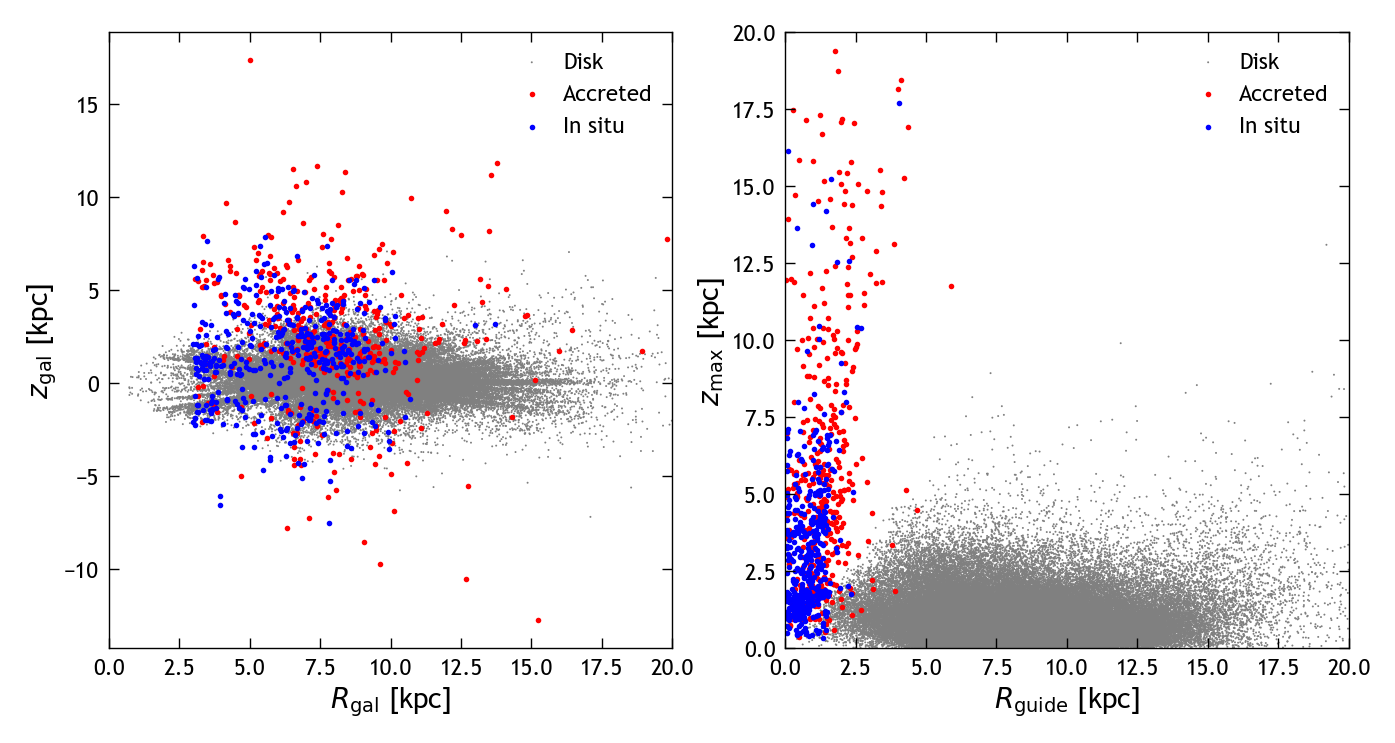

In [61]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].scatter(ad_disk['galr'], ad_disk['galz'], rasterized=True, s=0.5, edgecolors='none', c='gray', label='Disk')
axs[0].scatter(ad_accreted['galr'], ad_accreted['galz'], rasterized=True, s=1, c='r', label='Accreted')
axs[0].scatter(ad_insitu['galr'], ad_insitu['galz'], rasterized=True, s=1, c='b', label='In situ')
axs[0].legend()
axs[0].set_xlabel(r'$R_{\rm gal}$ [kpc]')
axs[0].set_ylabel(r'$z_{\rm gal}$ [kpc]')
axs[0].set_xlim((0, 20))

axs[1].scatter(ad_disk['Rg'], ad_disk['z_max'], rasterized=True, s=0.5, edgecolors='none', c='gray', label='Disk')
axs[1].scatter(ad_accreted['Rg'], ad_accreted['z_max'], rasterized=True, s=1, c='r', label='Accreted')
axs[1].scatter(ad_insitu['Rg'], ad_insitu['z_max'], rasterized=True, s=1, c='b', label='In situ')
axs[1].legend()
axs[1].set_xlabel(r'$R_{\rm guide}$ [kpc]')
axs[1].set_ylabel(r'$z_{\rm max}$ [kpc]')
axs[1].set_xlim((0, 20))
axs[1].set_ylim((0, 20))
plt.show()

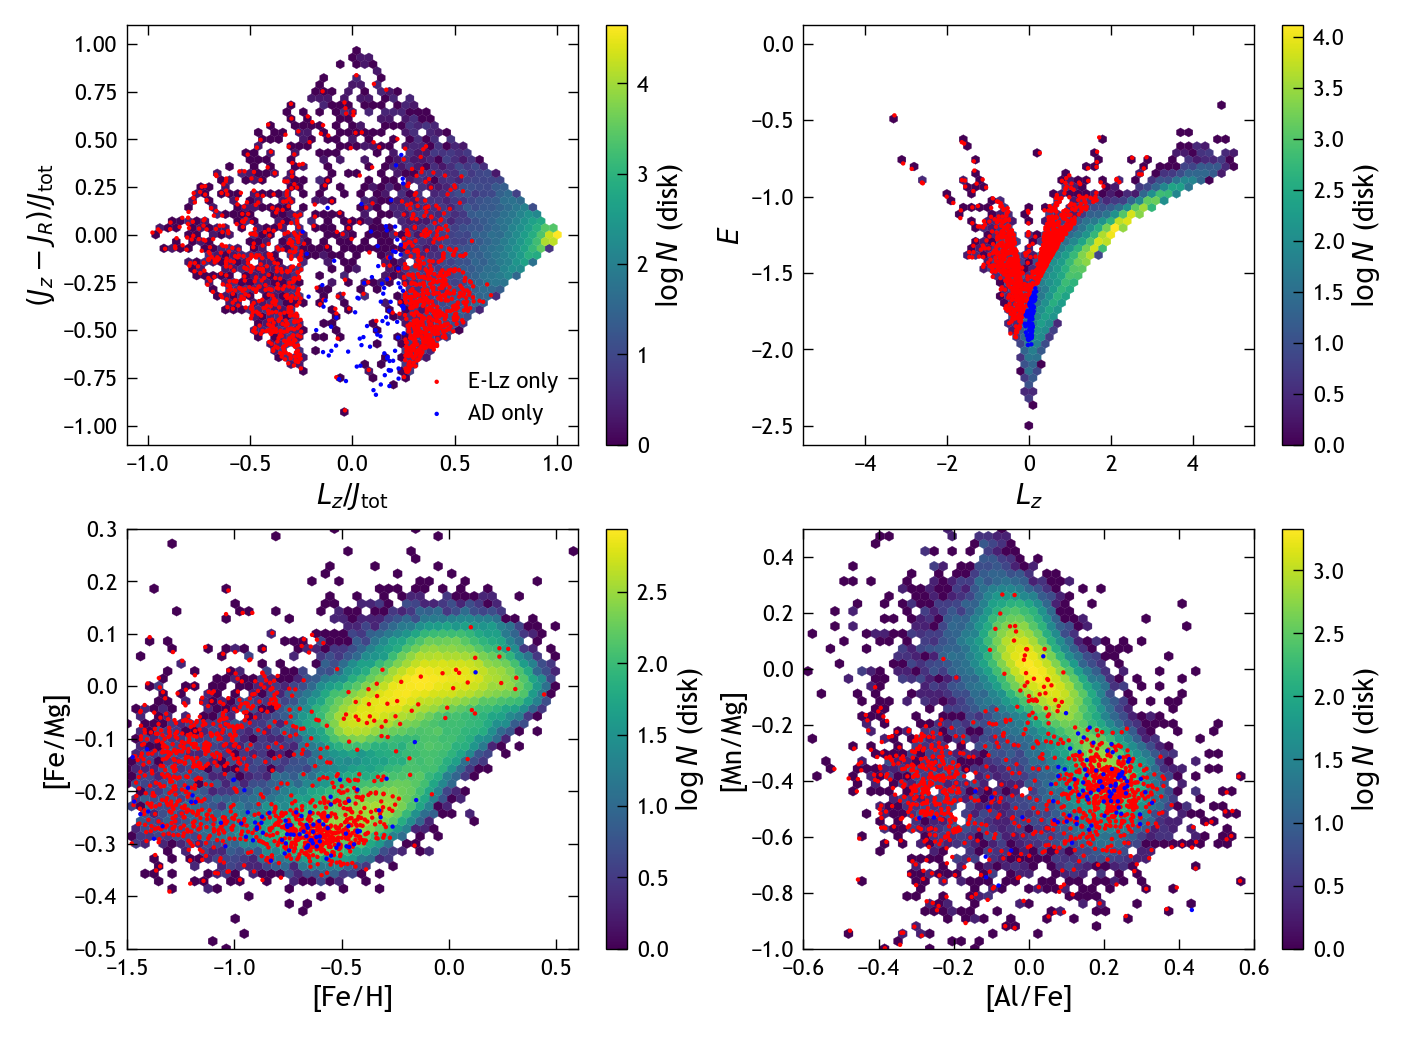

In [62]:
# Compare AD cut vs ELz cut

fig, axs = plt.subplots(2, 2, figsize=(8, 6))
ad_halo = sample[ad_halo_mask]
ad_disk = sample[~ad_halo_mask]
elz_halo_mask = sample['E']/1e5 > halo_ELz_cut(sample['Lz']/1e3)

elz_only = sample[
    elz_halo_mask & ~ad_halo_mask
]
ad_only = sample[
    ~elz_halo_mask & ad_halo_mask
]

# Panel 1: Action Diamond
kwargs = dict(gridsize=50, cmap='viridis', linewidths=0.1, vmin=0)
pcm = axs[0,0].hexbin(
    -ad_disk['Lz']/ad_disk['Jtot'], 
    (ad_disk['Jz']-ad_disk['Jr'])/ad_disk['Jtot'], 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[-1, 1, -1, 1],
    **kwargs
)
fig.colorbar(pcm, ax=axs[0,0], label=r'$\log N$ (disk)')
axs[0,0].scatter(
    -elz_only['Lz']/elz_only['Jtot'], 
    (elz_only['Jz']-elz_only['Jr'])/elz_only['Jtot'], 
    c='r', label='E-Lz only', **scatter_kwargs
)
axs[0,0].scatter(
    -ad_only['Lz']/ad_only['Jtot'], 
    (ad_only['Jz']-ad_only['Jr'])/ad_only['Jtot'], 
    c='b', label='AD only', **scatter_kwargs
)
axs[0,0].set_xlabel(r'$L_z/J_{\rm tot}$')
axs[0,0].set_ylabel(r'$(J_z - J_R)/J_{\rm tot}$')
axs[0,0].legend(loc='lower right')

# Panel 2: E-Lz diagram
pcm = axs[0,1].hexbin(
    -ad_disk['Lz']/1e3, 
    ad_disk['E']/1e5, 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[-5, 5, -2.5, 0.],
    **kwargs
)
fig.colorbar(pcm, ax=axs[0,1], label=r'$\log N$ (disk)')
axs[0,1].scatter(
    -elz_only['Lz']/1e3, 
    elz_only['E']/1e5, 
    c='r', label='E-Lz only', **scatter_kwargs
)
axs[0,1].scatter(
    -ad_only['Lz']/1e3, 
    ad_only['E']/1e5, 
    c='b', label='AD only', **scatter_kwargs
)
axs[0,1].set_xlabel(r'$L_z$')
axs[0,1].set_ylabel(r'$E$')

# Panel 3: alpha-Fe diagram
pcm = axs[1,0].hexbin(
    ad_disk['fe_h'], 
    ad_disk['fe_mg'], 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[-1.5, 0.6, -0.5, 0.3],
    **kwargs
)
fig.colorbar(pcm, ax=axs[1,0], label=r'$\log N$ (disk)')
axs[1,0].scatter(
    elz_only['fe_h'], 
    elz_only['fe_mg'], 
    c='r', label='E-Lz only', **scatter_kwargs
)
axs[1,0].scatter(
    ad_only['fe_h'], 
    ad_only['fe_mg'], 
    c='b', label='AD only', **scatter_kwargs
)
axs[1,0].set_xlabel('[Fe/H]')
axs[1,0].set_ylabel('[Fe/Mg]')
axs[1,0].set_xlim((-1.5, 0.6))
axs[1,0].set_ylim((-0.5, 0.3))

# Panel 4: chemistry diagram
pcm = axs[1,1].hexbin(
    ad_disk['al_fe'], 
    ad_disk['mn_mg'], 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[-0.6, 0.6, -1, 0.5],
    **kwargs
)
fig.colorbar(pcm, ax=axs[1,1], label=r'$\log N$ (disk)')
axs[1,1].scatter(
    elz_only['al_fe'], 
    elz_only['mn_mg'], 
    c='r', label='E-Lz only', **scatter_kwargs
)
axs[1,1].scatter(
    ad_only['al_fe'], 
    ad_only['mn_mg'], 
    c='b', label='AD only', **scatter_kwargs
)
axs[1,1].set_xlabel('[Al/Fe]')
axs[1,1].set_ylabel('[Mn/Mg]')
axs[1,1].set_xlim((-0.6, 0.6))
axs[1,1].set_ylim((-1, 0.5))

plt.show()

In [63]:
print(elz_only.shape)
print(ad_only.shape)

(1121, 477)
(87, 477)


In [64]:
print(ad_halo.shape)

(918, 477)


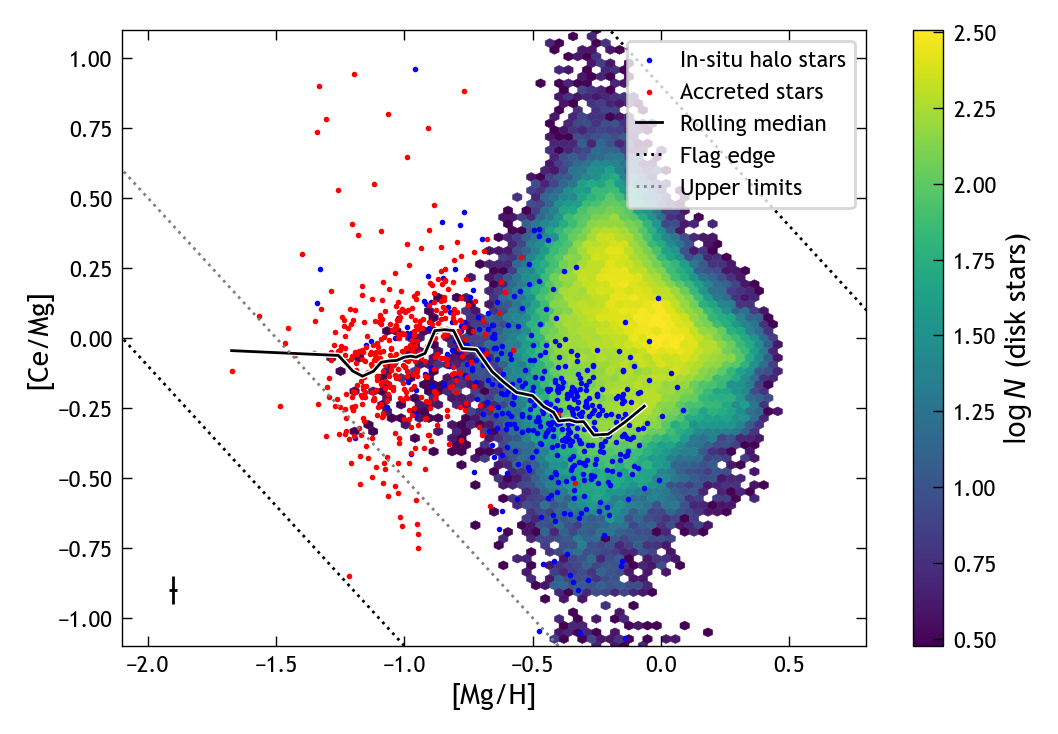

In [65]:
fig, ax = plt.subplots(figsize=(6, 4))

kwargs = dict(gridsize=80, cmap='viridis', linewidths=0.2, extent=[-2.1, 0.8, -1.1, 1.1], mincnt=3)
pcm = ax.hexbin(
    mwm_disk['mg_h'], mwm_disk['ce_mg'], 
    C=np.ones(sample.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$ (disk stars)')

ax.scatter(ad_insitu['mg_h'], ad_insitu['ce_mg'], rasterized=True, s=1, c='b', label='In-situ halo stars')
ax.scatter(ad_accreted['mg_h'], ad_accreted['ce_mg'], rasterized=True, s=1, c='r', label='Accreted stars')

# Indicate median abundance error
ax.errorbar(
    -1.9, -0.9, 
    xerr=sample['e_mg_h'].median(), 
    yerr=sample['e_ce_mg'].median(),
    c='k', capsize=0
)

# Rolling median
sorted_data = ad_halo.sort_values('mg_h')[['mg_h', 'ce_mg']]
rolling_medians = sorted_data.rolling(
    100, min_periods=30, step=30, on='mg_h', center=True
).median()
ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], 'w-', linewidth=2)
ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], 'k-', label='Rolling median')

# Indicate grid edges
mgh_arr = np.arange(-2.5, 1.25, 0.25)
# ax.plot(mgh_arr, -2.5 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, -2.1 - mgh_arr, 'k:', label='Flag edge') # edge of stars flagged bad
ax.plot(mgh_arr, -1.5 - mgh_arr, color='gray', ls=':', label='Upper limits') # indicates region of upper limits (manual)
# ax.plot(mgh_arr, 1 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, 0.9 - mgh_arr, 'k:') # edge of stars flagged bad

ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend(frameon=True, loc='upper right')

plt.show()

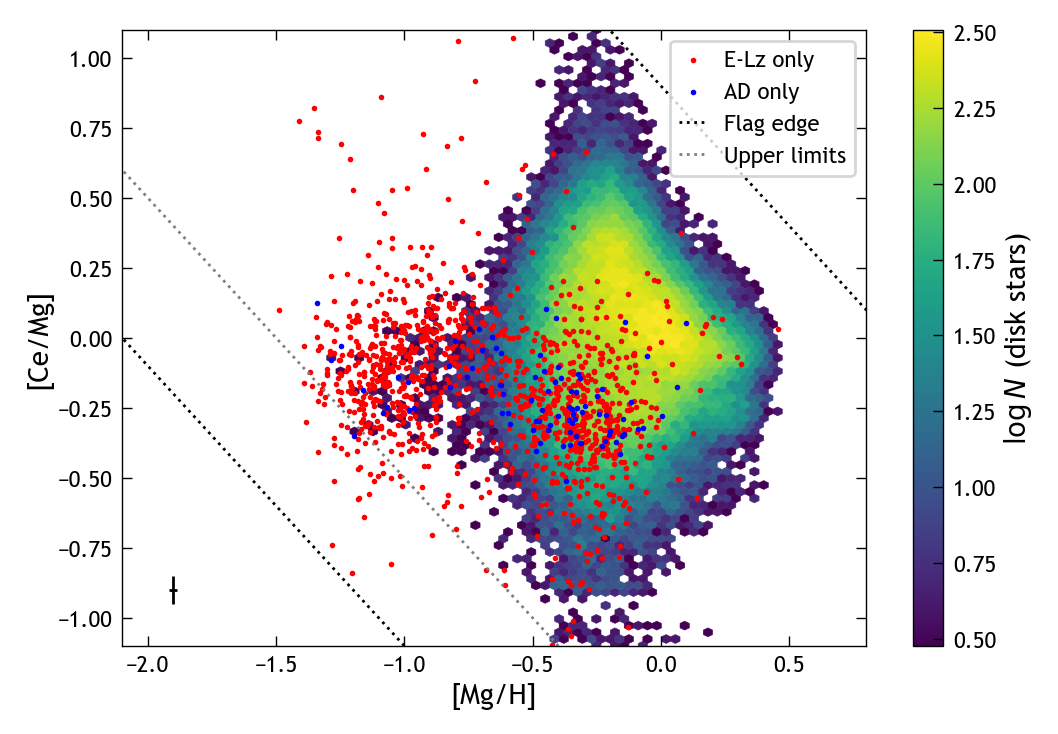

In [66]:
fig, ax = plt.subplots(figsize=(6, 4))

kwargs = dict(gridsize=80, cmap='viridis', linewidths=0.2, extent=[-2.1, 0.8, -1.1, 1.1], mincnt=3)
pcm = ax.hexbin(
    mwm_disk['mg_h'], mwm_disk['ce_mg'], 
    C=np.ones(sample.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$ (disk stars)')

ax.scatter(elz_only['mg_h'], elz_only['ce_mg'], rasterized=True, s=1, c='r', label='E-Lz only')
ax.scatter(ad_only['mg_h'], ad_only['ce_mg'], rasterized=True, s=1, c='b', label='AD only')

# Indicate median abundance error
ax.errorbar(
    -1.9, -0.9, 
    xerr=sample['e_mg_h'].median(), 
    yerr=sample['e_ce_mg'].median(),
    c='k', capsize=0
)

# Indicate grid edges
mgh_arr = np.arange(-2.5, 1.25, 0.25)
# ax.plot(mgh_arr, -2.5 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, -2.1 - mgh_arr, 'k:', label='Flag edge') # edge of stars flagged bad
ax.plot(mgh_arr, -1.5 - mgh_arr, color='gray', ls=':', label='Upper limits') # indicates region of upper limits (manual)
# ax.plot(mgh_arr, 1 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, 0.9 - mgh_arr, 'k:') # edge of stars flagged bad

ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend(frameon=True, loc='upper right')

plt.show()

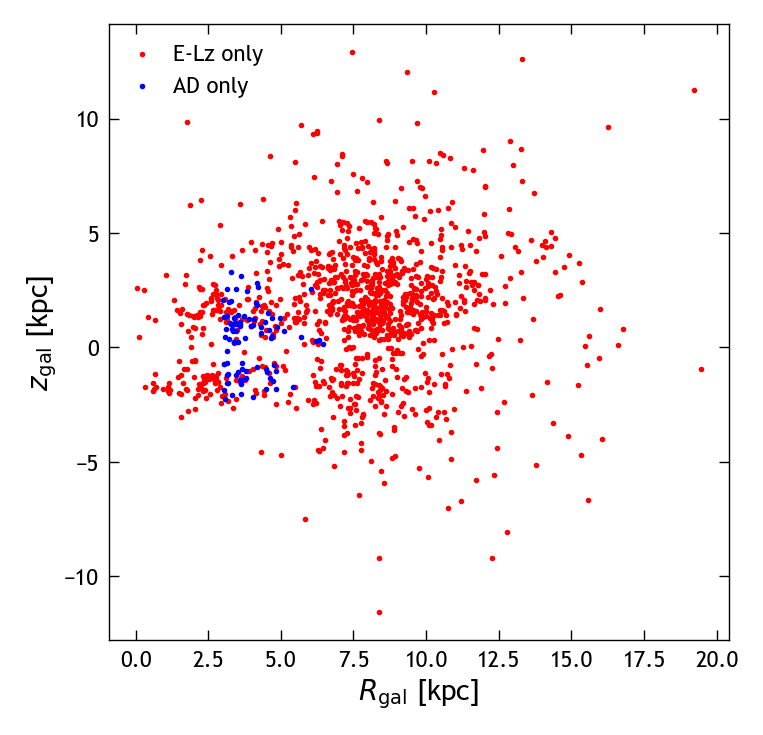

In [67]:
fig, ax = plt.subplots()
ax.scatter(elz_only['galr'], elz_only['galz'], rasterized=True, s=1, c='r', label='E-Lz only')
ax.scatter(ad_only['galr'], ad_only['galz'], rasterized=True, s=1, c='b', label='AD only')
ax.legend()
ax.set_xlabel(r'$R_{\rm gal}$ [kpc]')
ax.set_ylabel(r'$z_{\rm gal}$ [kpc]')
plt.show()

## GSE selection

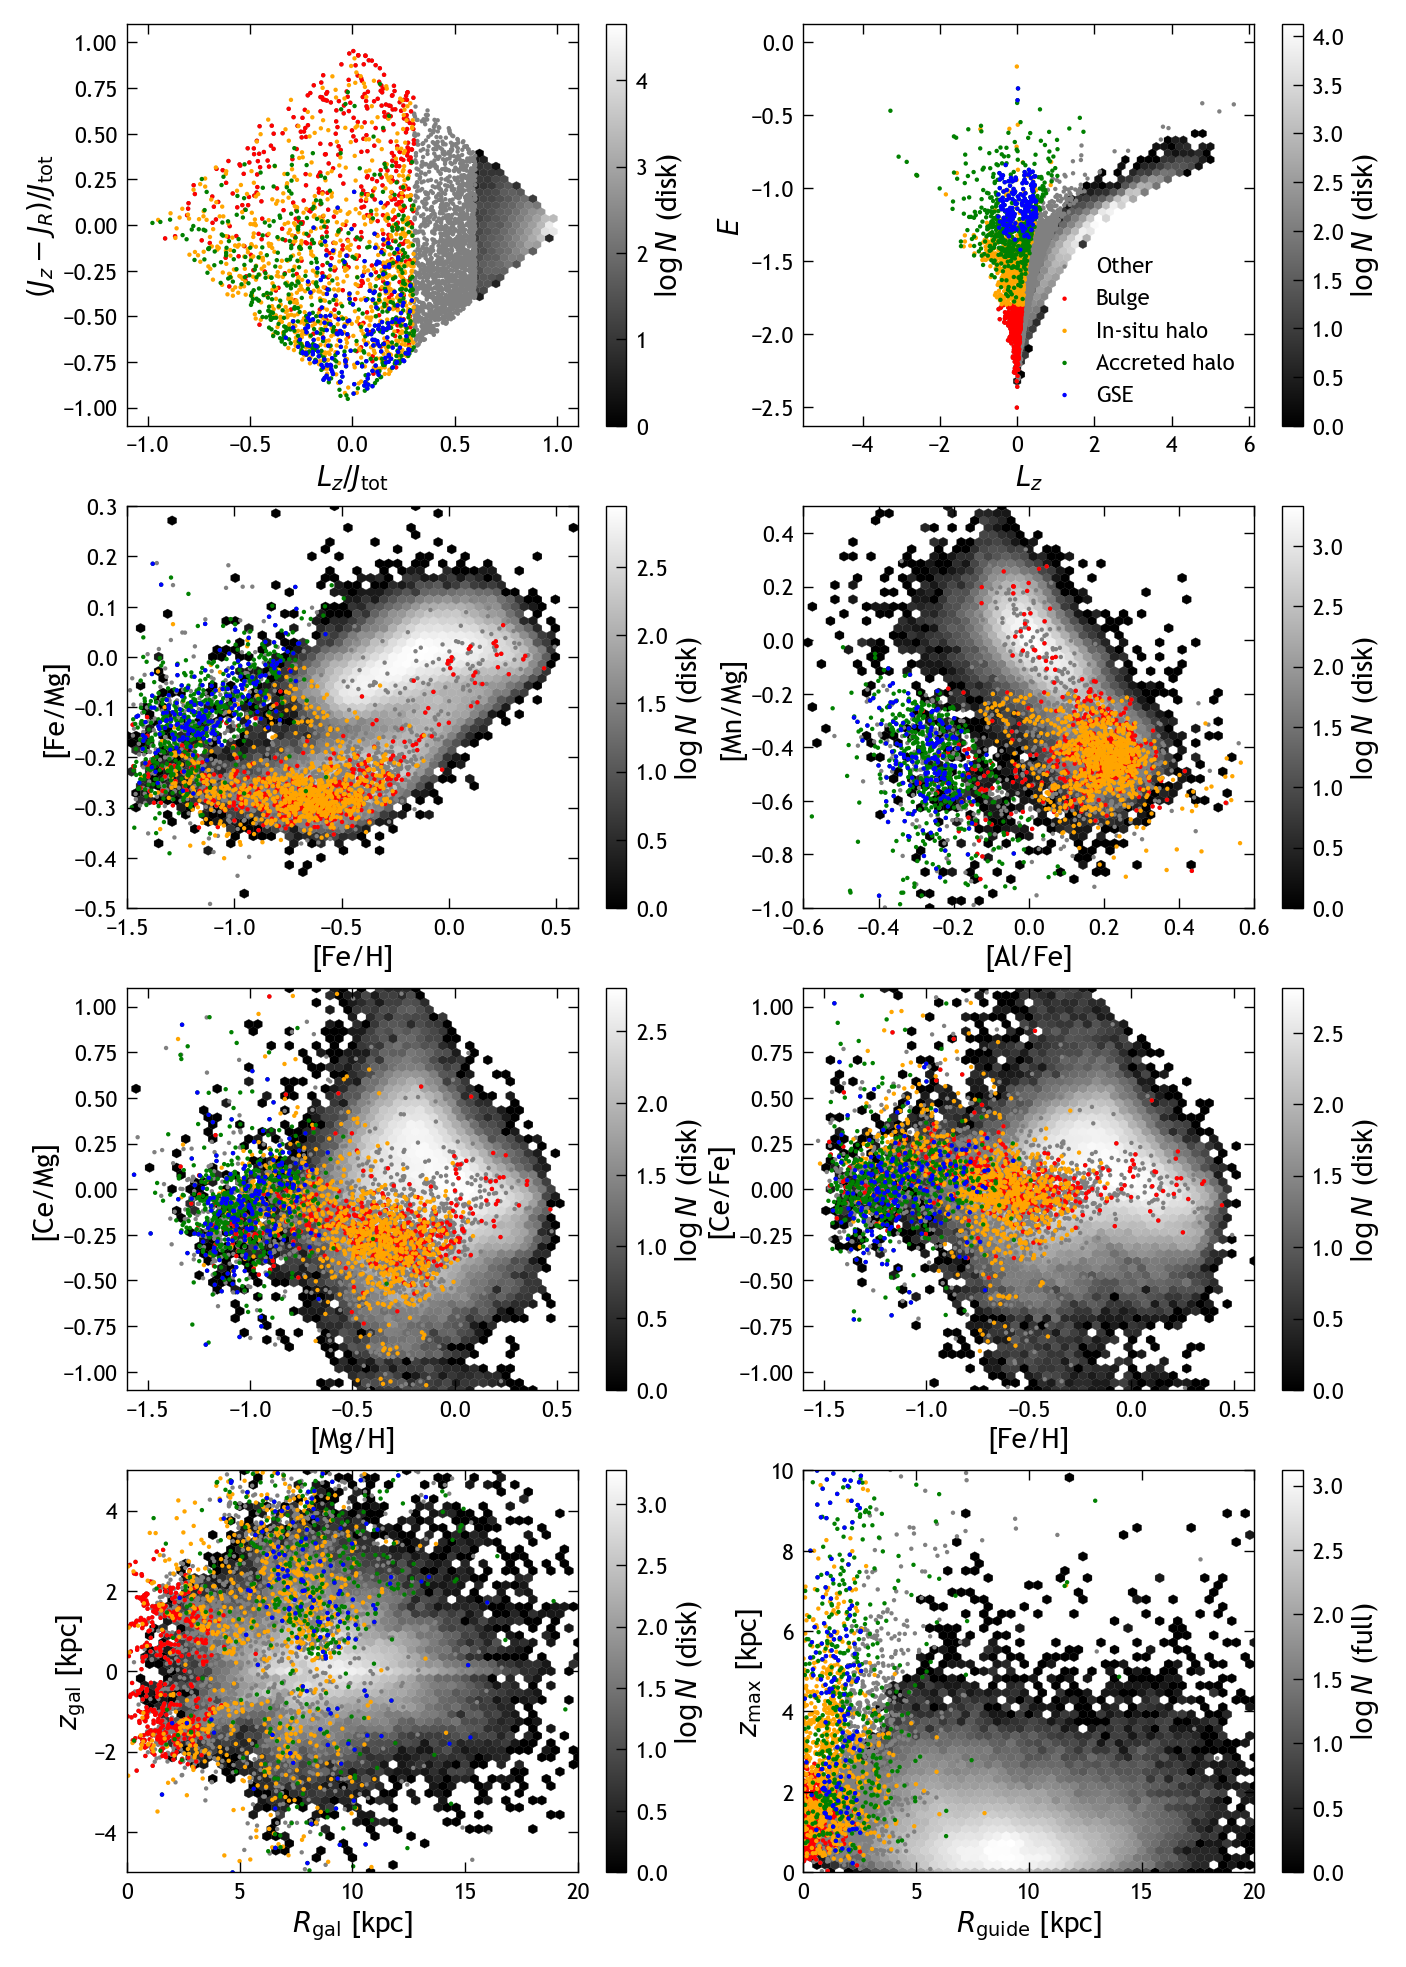

In [99]:
ad_halo_mask = (sample['Lz']/sample['Jtot'] > -0.3) & (sample['E']/1e5 > -1.8)# & (sample['galz'].abs() > 1)
ad_bulge_mask = (sample['Lz']/sample['Jtot'] > -0.3) & (sample['E']/1e5 <= -1.8)
ad_disk_mask = sample['Lz']/sample['Jtot'] < -0.6

chem_accreted_mask = (sample['mn_mg'] < -0.65-2*sample['al_fe'])
chem_insitu_mask = (sample['mn_mg'] > -0.55-2*sample['al_fe']) & (sample['mn_mg'] < -0.2)

ad_disk = sample[ad_disk_mask]
ad_other = sample[(~ad_disk_mask) & (~ad_halo_mask)]
accreted_halo = sample[ad_halo_mask & chem_accreted_mask]
insitu_halo = sample[ad_halo_mask & chem_insitu_mask]
insitu_bulge = sample[ad_bulge_mask]

# Feuillet et al. (2020) selection
feuillet_gse_mask = (
    (np.sqrt(sample['Jr']) > 30) &
    (np.sqrt(sample['Jr']) < 50) &
    (sample['Lz'] > -500) &
    (sample['Lz'] < 500)
)
gse = sample[feuillet_gse_mask & chem_accreted_mask]

fig, axs = plt.subplots(4, 2, figsize=(8, 12))
kwargs = dict(gridsize=50, cmap='binary_r', linewidths=0.1, vmin=0)

logsum = lambda x: np.log10(np.sum(x))
x = -sample['Lz']/sample['Jtot']-1
y = (sample['Jz']-sample['Jr'])/sample['Jtot']

subsamples = [ad_other, insitu_bulge, insitu_halo, accreted_halo, gse]
colors = ['gray', 'r', 'orange', 'g', 'b']
labels = ['Other', 'Bulge', 'In-situ halo', 'Accreted halo', 'GSE']

# Panel 1: Action Diamond
pcm = axs[0,0].hexbin(
    -ad_disk['Lz']/ad_disk['Jtot'], 
    (ad_disk['Jz']-ad_disk['Jr'])/ad_disk['Jtot'], 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[-1, 1, -1, 1],
    **kwargs
)
fig.colorbar(pcm, ax=axs[0,0], label=r'$\log N$ (disk)')
for i, df in enumerate(subsamples):
    axs[0,0].scatter(
        -df['Lz']/df['Jtot'], 
        (df['Jz']-df['Jr'])/df['Jtot'], 
        c=colors[i], label=labels[i], **scatter_kwargs
    )
axs[0,0].set_xlabel(r'$L_z/J_{\rm tot}$')
axs[0,0].set_ylabel(r'$(J_z - J_R)/J_{\rm tot}$')

# Panel 2: E-Lz diagram
pcm = axs[0,1].hexbin(
    -ad_disk['Lz']/1e3, 
    ad_disk['E']/1e5, 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[-5, 5, -2.5, 0.],
    **kwargs
)
fig.colorbar(pcm, ax=axs[0,1], label=r'$\log N$ (disk)')
for i, df in enumerate(subsamples):
    axs[0,1].scatter(
        -df['Lz']/1e3, 
        df['E']/1e5, 
        c=colors[i], label=labels[i], **scatter_kwargs
    )
axs[0,1].set_xlabel(r'$L_z$')
axs[0,1].set_ylabel(r'$E$')
axs[0,1].legend(loc='lower right')

# Panel 3: alpha-Fe diagram
pcm = axs[1,0].hexbin(
    ad_disk['fe_h'], 
    ad_disk['fe_mg'], 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[-1.5, 0.6, -0.5, 0.3],
    **kwargs
)
fig.colorbar(pcm, ax=axs[1,0], label=r'$\log N$ (disk)')
for i, df in enumerate(subsamples):
    axs[1,0].scatter(
        df['fe_h'], 
        df['fe_mg'], 
        c=colors[i], label=labels[i], **scatter_kwargs
    )
axs[1,0].set_xlabel('[Fe/H]')
axs[1,0].set_ylabel('[Fe/Mg]')
axs[1,0].set_xlim((-1.5, 0.6))
axs[1,0].set_ylim((-0.5, 0.3))

# Panel 4: chemistry diagram
pcm = axs[1,1].hexbin(
    ad_disk['al_fe'], 
    ad_disk['mn_mg'], 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[-0.6, 0.6, -1, 0.5],
    **kwargs
)
fig.colorbar(pcm, ax=axs[1,1], label=r'$\log N$ (disk)')
for i, df in enumerate(subsamples):
    axs[1,1].scatter(
        df['al_fe'], 
        df['mn_mg'], 
        c=colors[i], label=labels[i], **scatter_kwargs
    )
axs[1,1].set_xlabel('[Al/Fe]')
axs[1,1].set_ylabel('[Mn/Mg]')
axs[1,1].set_xlim((-0.6, 0.6))
axs[1,1].set_ylim((-1, 0.5))

# Panel 5: [Ce/Mg] vs [Mg/H]
pcm = axs[2,0].hexbin(
    ad_disk['mg_h'], 
    ad_disk['ce_mg'], 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[-1.6, 0.6, -1.1, 1.1],
    **kwargs
)
fig.colorbar(pcm, ax=axs[2,0], label=r'$\log N$ (disk)')
for i, df in enumerate(subsamples):
    axs[2,0].scatter(
        df['mg_h'], 
        df['ce_mg'], 
        c=colors[i], label=labels[i], **scatter_kwargs
    )
axs[2,0].set_xlabel('[Mg/H]')
axs[2,0].set_ylabel('[Ce/Mg]')
axs[2,0].set_xlim((-1.6, 0.6))
axs[2,0].set_ylim((-1.1, 1.1))

# Panel 6: [Ce/Fe]-[Fe/H] diagram
pcm = axs[2,1].hexbin(
    ad_disk['fe_h'], 
    ad_disk['ce_fe'], 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[-1.6, 0.6, -1.1, 1.1],
    **kwargs
)
fig.colorbar(pcm, ax=axs[2,1], label=r'$\log N$ (disk)')
for i, df in enumerate(subsamples):
    axs[2,1].scatter(
        df['fe_h'], 
        df['ce_fe'], 
        c=colors[i], label=labels[i], **scatter_kwargs
    )
axs[2,1].set_xlabel('[Fe/H]')
axs[2,1].set_ylabel('[Ce/Fe]')
axs[2,1].set_xlim((-1.6, 0.6))
axs[2,1].set_ylim((-1.1, 1.1))

# Panel 7: galr-galz diagram
pcm = axs[3,0].hexbin(
    ad_disk['galr'], 
    ad_disk['galz'], 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[0, 20, -5, 5],
    **kwargs
)
fig.colorbar(pcm, ax=axs[3,0], label=r'$\log N$ (disk)')
for i, df in enumerate(subsamples):
    axs[3,0].scatter(
        df['galr'], 
        df['galz'], 
        c=colors[i], label=labels[i], **scatter_kwargs
    )
axs[3,0].set_xlabel(r'$R_{\rm gal}$ [kpc]')
axs[3,0].set_ylabel(r'$z_{\rm gal}$ [kpc]')
axs[3,0].set_xlim((0, 20))
axs[3,0].set_ylim((-5, 5))

# Panel 8: Rguide-zmax diagram
pcm = axs[3,1].hexbin(
    ad_disk['Rg'], 
    ad_disk['z_max'], 
    C=np.ones(ad_disk.shape[0]),
    reduce_C_function=logsum,
    extent=[0, 20, 0, 10],
    **kwargs
)
fig.colorbar(pcm, ax=axs[3,1], label=r'$\log N$ (full)')
for i, df in enumerate(subsamples):
    axs[3,1].scatter(
        df['Rg'], 
        df['z_max'], 
        c=colors[i], label=labels[i], **scatter_kwargs
    )
axs[3,1].set_xlabel(r'$R_{\rm guide}$ [kpc]')
axs[3,1].set_ylabel(r'$z_{\rm max}$ [kpc]')
axs[3,1].set_xlim((0, 20))
axs[3,1].set_ylim((0, 10))

plt.show()